# In This Hands-On: Fine-Tuning GPT via OpenAI API

In this hands-on, we will fine-tune a GPT-3.5 Turbo model using OpenAI’s managed fine-tuning API. The entire process will be conducted in Google Colab, with no need for local GPUs. We will:

- Prepare and format a custom instruction-style dataset (chat format using `messages`)
- Upload and validate the dataset via the OpenAI Python SDK
- Launch a fine-tuning job on OpenAI’s hosted infrastructure
- Monitor fine-tuning progress programmatically
- Compare model responses before and after fine-tuning
- Save the model ID for future reuse in apps and scripts

Note: No need to manage GPUs, memory, or training loops — all training runs on OpenAI’s infrastructure.


## Install and Import OpenAI SDK

In [1]:
!pip install openai --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 735.8/735.8 kB 11.6 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.86.0
    Uninstalling openai-1.86.0:
      Successfully uninstalled openai-1.86.0


## Set Your API Key
Don't hardcode your key. You can use Colab secrets.
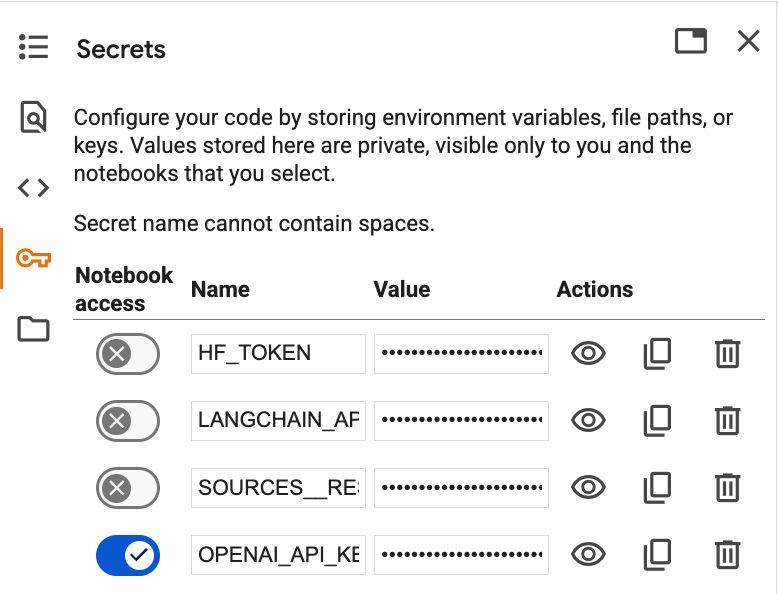


In [31]:
import openai
from google.colab import userdata

# Use Colab secrets to store your API key
# Retrieve the API key and store it to variable
openai.api_key = userdata.get("OPENAI_API_KEY")

## Use or Create Our Own Data for Fine-tune
In this scenario we synthethize purwadhika FAQ data

In [21]:
import json

data = [
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apa itu Purwadhika?"},
            {"role": "assistant", "content": "Purwadhika adalah institusi pendidikan teknologi yang menawarkan program seperti Data Science, Web Development, dan Digital Marketing dalam format bootcamp intensif."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Program apa saja yang tersedia di Purwadhika?"},
            {"role": "assistant", "content": "Purwadhika menawarkan berbagai program, seperti Data Science, Software Engineering, UI/UX Design, dan Digital Marketing."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apakah saya harus memiliki latar belakang IT untuk ikut bootcamp?"},
            {"role": "assistant", "content": "Tidak perlu. Purwadhika menerima peserta dari berbagai latar belakang dan menyediakan materi dasar sebelum masuk ke topik lanjutan."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apakah bootcamp ini online atau offline?"},
            {"role": "assistant", "content": "Purwadhika menyediakan pilihan belajar secara online maupun offline, tergantung pada program dan lokasi."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Berapa lama durasi bootcamp di Purwadhika?"},
            {"role": "assistant", "content": "Durasi bootcamp biasanya antara 12 hingga 20 minggu tergantung pada program yang diambil."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apa itu Purwadhika?"},
            {"role": "assistant", "content": "Purwadhika adalah institusi pendidikan teknologi yang menawarkan program seperti Data Science, Web Development, dan Digital Marketing dalam format bootcamp intensif."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Program apa saja yang tersedia di Purwadhika?"},
            {"role": "assistant", "content": "Purwadhika menawarkan berbagai program, seperti Data Science, Software Engineering, UI/UX Design, dan Digital Marketing."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apakah saya harus memiliki latar belakang IT untuk ikut bootcamp?"},
            {"role": "assistant", "content": "Tidak perlu. Purwadhika menerima peserta dari berbagai latar belakang dan menyediakan materi dasar sebelum masuk ke topik lanjutan."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apakah bootcamp ini online atau offline?"},
            {"role": "assistant", "content": "Purwadhika menyediakan pilihan belajar secara online maupun offline, tergantung pada program dan lokasi."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Berapa lama durasi bootcamp di Purwadhika?"},
            {"role": "assistant", "content": "Durasi bootcamp biasanya antara 12 hingga 20 minggu tergantung pada program yang diambil."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apa itu Purwadhika?"},
            {"role": "assistant", "content": "Purwadhika adalah institusi pendidikan teknologi yang menawarkan program seperti Data Science, Web Development, dan Digital Marketing dalam format bootcamp intensif."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Program apa saja yang tersedia di Purwadhika?"},
            {"role": "assistant", "content": "Purwadhika menawarkan berbagai program, seperti Data Science, Software Engineering, UI/UX Design, dan Digital Marketing."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apakah saya harus memiliki latar belakang IT untuk ikut bootcamp?"},
            {"role": "assistant", "content": "Tidak perlu. Purwadhika menerima peserta dari berbagai latar belakang dan menyediakan materi dasar sebelum masuk ke topik lanjutan."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Apakah bootcamp ini online atau offline?"},
            {"role": "assistant", "content": "Purwadhika menyediakan pilihan belajar secara online maupun offline, tergantung pada program dan lokasi."}
        ]
    },
    {
        "messages": [
            {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
            {"role": "user", "content": "Berapa lama durasi bootcamp di Purwadhika?"},
            {"role": "assistant", "content": "Durasi bootcamp biasanya antara 12 hingga 20 minggu tergantung pada program yang diambil."}
        ]
    }
]

# Save to JSONL
with open("purwadhika_faq.jsonl", "w") as f:
    for entry in data:
        json.dump(entry, f)
        f.write("\n")

## Upload and Validate Dataset

In [23]:
file = openai.files.create(
    file=open("purwadhika_faq.jsonl", "rb"),
    purpose="fine-tune"
)

print(f"Uploaded file ID: {file.id}")

Uploaded file ID: file-FCMVpgWZHJkJX4VXq2mBJb


## Create Fine-tuning Job
It takes approximately 30 minutes to fine-tune the LLM

In [24]:
fine_tune_job = openai.fine_tuning.jobs.create(
    training_file=file.id,
    model="gpt-3.5-turbo"
)

print(f"Fine-tune Job ID: {fine_tune_job.id}")

Fine-tune Job ID: ftjob-RRWTWFCrVzqqYk34Lb5CdMNN


## Monitor the Job

In [30]:
import time
from datetime import datetime

job_id = fine_tune_job.id  # or replace with your actual job ID string

print(f"Monitoring fine-tuning job: {job_id}")
print("Press ⏹️ (stop) in Colab if you want to cancel monitoring early.\n")

while True:
    job = openai.fine_tuning.jobs.retrieve(job_id)
    status = job.status
    now = datetime.now().strftime("%H:%M:%S")
    print(f"[{now}] Status: {status}")

    if status in ["succeeded", "failed", "cancelled"]:
        print(f"Final status: {status}")
        break

    time.sleep(10)  # check every 10 seconds

Monitoring fine-tuning job: ftjob-RRWTWFCrVzqqYk34Lb5CdMNN
Press ⏹️ (stop) in Colab if you want to cancel monitoring early.

[03:06:05] Status: running
[03:06:15] Status: running
[03:06:25] Status: running
[03:06:35] Status: running
[03:06:46] Status: running
[03:06:56] Status: running
[03:07:06] Status: running
[03:07:16] Status: running
[03:07:26] Status: running
[03:07:37] Status: running
[03:07:47] Status: running
[03:07:57] Status: running
[03:08:07] Status: running
[03:08:17] Status: running
[03:08:28] Status: running
[03:08:38] Status: running
[03:08:48] Status: running
[03:08:58] Status: running
[03:09:08] Status: running
[03:09:18] Status: running
[03:09:29] Status: running
[03:09:39] Status: running
[03:09:49] Status: running
[03:09:59] Status: running
[03:10:09] Status: running
[03:10:20] Status: running
[03:10:30] Status: running
[03:10:40] Status: running
[03:10:50] Status: running
[03:11:00] Status: running
[03:11:11] Status: running
[03:11:21] Status: running
[03:11:31] 

## Use the Fine-tuned Model

In [46]:
from openai import OpenAI

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

# Define the prompt
messages = [
    {"role": "system", "content": "You are a helpful assistant for Purwadhika Bootcamp."},
    {"role": "user", "content": "Berapa lama durasi bootcamp di Purwadhika?"}
]

# Fine-tuned model
fine_tuned_model = job.fine_tuned_model

fine_tuned_response = client.chat.completions.create(
    model=fine_tuned_model,
    messages=messages
)

# Base model (non-fine-tuned)
base_response = client.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=messages
)

# Show results
print("🔧 Fine-tuned model response:\n")
print(fine_tuned_response.choices[0].message.content)

print("\n🧠 Base model response:\n")
print(base_response.choices[0].message.content)


🔧 Fine-tuned model response:

Durasi bootcamp biasanya antara 12 hingga 20 minggu tergantung pada program yang diambil.

🧠 Base model response:

Durasi bootcamp di Purwadhika bervariasi tergantung pada program yang diikuti. Umumnya, bootcamp di Purwadhika memiliki durasi sekitar 12-16 minggu. Namun, ada juga program-program khusus yang durasinya lebih pendek atau lebih panjang. Jika Anda tertarik untuk bergabung, sebaiknya langsung mengunjungi situs web resmi Purwadhika atau menghubungi pihak terkait untuk informasi lebih lanjut.


## Save the fine-tuned model id

In [47]:
print(job.fine_tuned_model)

ft:gpt-3.5-turbo-0125:purwadhika::BloC4fRN


In [48]:
# Save model ID to a file
with open("fine_tuned_model_id.txt", "w") as f:
    f.write(job.fine_tuned_model)